# Imports

In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi


In [2]:
# Change directory
os.chdir('/content/drive/MyDrive/nids-mitre/')

!pwd


/content/drive/MyDrive/nids-mitre


# Functions

## Load data

In [3]:
def load_json_losses(base_log_path="results_earlystopping/logs"):
    """
    Read the individual JSON by seed and extract the losses and early stopping
    Return: {'ModelName': {'seed_99': {'train': [...], 'val': [...], 'val_aucpr': [...], 'best_epoch': 25}, ...}}
    """
    losses = {}
    if not os.path.exists(base_log_path):
        print(f"Path not found: {base_log_path}")
        return losses

    for raw_model_name in os.listdir(base_log_path):
        model_dir = os.path.join(base_log_path, raw_model_name)
        if not os.path.isdir(model_dir): continue

        clean_model_name = MODEL_NAME_MAPPING.get(raw_model_name, raw_model_name)
        losses[raw_model_name] = {}
        json_files = glob.glob(os.path.join(model_dir, "*.json"))

        for jf in json_files:
            with open(jf, 'r') as f:
                data = json.load(f)

            if 'training' in data:
                seed_id = f"seed_{data.get('seed', 'unknown')}"

                losses[raw_model_name][seed_id] = {
                    'train': data['training'].get('train_loss', []),
                    'val': data['training'].get('val_loss', []),
                    'val_aucpr': data['training'].get('val_aucpr', []),
                    'best_epoch': data.get('early_stopping', {}).get('best_epoch', None)
                }

    return losses



In [4]:
def load_and_merge_csv_data(base_log_path="results_earlystopping/logs"):
    df_list = []
    if not os.path.exists(base_log_path): return None

    for raw_model_name in os.listdir(base_log_path):
        csv_files = glob.glob(os.path.join(base_log_path, raw_model_name, "*.csv"))
        clean_model_name = MODEL_NAME_MAPPING.get(raw_model_name, raw_model_name)
        for csv_file in csv_files:
            df = pd.read_csv(csv_file)
            df.columns = df.columns.str.lower().str.strip()
            df['model'] = clean_model_name
            if len(df) > 0:
                df_list.append(df)

    if not df_list: return None
    return pd.concat(df_list, ignore_index=True)

## Training losses

In [5]:
def plot_training_losses(losses_data, plots_dir="./plots"):
    """ Plot the mean and standard deviation band for each model """
    os.makedirs(plots_dir, exist_ok=True)

    plt.figure(figsize=(12, 6))

    for raw_model_name, seed_dict in losses_data.items():
        if not seed_dict: continue

        clean_model_name = MODEL_NAME_MAPPING.get(raw_model_name, raw_model_name)
        # Collect all training curves
        all_train_losses = [data['train'] for data in seed_dict.values() if 'train' in data]
        if not all_train_losses: continue

        # Truncate to minimum size to align matrices
        min_len = min(len(lst) for lst in all_train_losses)
        matrix = np.array([lst[:min_len] for lst in all_train_losses])

        mean_loss = np.mean(matrix, axis=0)
        std_loss = np.std(matrix, axis=0)
        epochs = range(1, len(mean_loss) + 1)

        color = colors.get(clean_model_name, '#333333')
        plt.plot(epochs, mean_loss, label=clean_model_name, color=color, linewidth=2)
        plt.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, color=color, alpha=0.15)

    plt.title("Training Stability & Convergence (Mean ± Std)", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Training Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/training_losses_comparison.png", dpi=300)
    plt.show()



In [6]:
def plot_losses_train_val_per_model(losses_data, raw_model_name, plots_dir="./plots"):
    """ Plot Train vs Val for all seeds and mark the Early Stopping """
    os.makedirs(plots_dir, exist_ok=True)

    if raw_model_name not in losses_data or not losses_data[raw_model_name]:
        print(f"There is no data for {raw_model_name}")
        return

    clean_model_name = MODEL_NAME_MAPPING.get(raw_model_name, raw_model_name)

    plt.figure(figsize=(12, 6))
    palette = sns.color_palette("husl", len(losses_data[raw_model_name]))

    for i, (seed_name, metrics) in enumerate(losses_data[raw_model_name].items()):
        if 'train' not in metrics or 'val' not in metrics: continue

        train_loss = metrics['train']
        val_loss = metrics['val']
        best_epoch = metrics.get('best_epoch', None)

        epochs = range(len(train_loss))
        color = palette[i]

        plt.plot(epochs, train_loss, linestyle='-', color=color, alpha=0.4)
        plt.plot(epochs, val_loss, linestyle='--', color=color, linewidth=2, label=f'{seed_name}')

        if best_epoch is not None and best_epoch <= len(val_loss):
            idx = best_epoch
            val_at_best = val_loss[idx]
            plt.scatter(best_epoch, val_at_best, color=color, s=100, zorder=5, marker='*', edgecolor='black')

    plt.title(f"{clean_model_name} - Train vs Validation Loss (Stars = Best Epoch)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Validation Sets")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/{raw_model_name}/{clean_model_name.replace(' ', '_')}_train_val_loss.png", dpi=300)
    plt.show()

## Comparative bar chart (with error bars)

In [7]:
def plot_comparison(df, plots_dir="./plots"):
    metrics_to_plot = ['precision', 'recall', 'f1', 'f2', 'auc-pr', 'auc-roc']
    available = [m for m in metrics_to_plot if m in df.columns]
    if not available: return

    df_melted = df.melt(id_vars=['model'], value_vars=available, var_name='Metric', value_name='Value')
    df_melted['Metric'] = df_melted['Metric'].str.upper()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melted, x='Metric', y='Value', hue='model', palette=colors, errorbar='sd', capsize=0.1)
    plt.title("Model Comparison (Optimal Threshold)", fontsize=14)
    plt.ylim(0.0, 1.1)
    plt.legend(title='Architecture')
    plt.ylabel("Score")
    plt.xlabel("")
    plt.tight_layout()
    plt.savefig(f"{plots_dir}/metrics_comparison_barplot.png", dpi=300)
    plt.show()

## Radar chart

In [16]:
def plot_radar_chart(df, plots_dir="./plots"):
    # Group by model and calculate average
    # Select only numeric columns for the average
    df_avg = df.groupby('model', observed=False).mean(numeric_only=True).reset_index()

    metrics_to_plot = ['precision', 'recall', 'f1', 'f2', 'auc-pr', 'auc-roc']

    # Prepare the plot
    categories = [m.upper() for m in metrics_to_plot]
    N = len(categories)

    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Closing the circle

    plt.figure(figsize=(10, 10))
    ax = plt.subplot(111, polar=True)

    # Axes and Labels
    plt.xticks(angles[:-1], categories, color='black', size=12)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=10)
    plt.ylim(0, 1)

    draw_order = ["Simple MLP", "Edge GRU", "Static GNN", "ST-GNN (Ours)"]

    for model_name in draw_order:
        if model_name not in df_avg['model'].values: continue

        # Obtain values ​​and close the circle
        values = df_avg[df_avg['model'] == model_name][metrics_to_plot].values.flatten().tolist()
        values += values[:1]

        col = colors.get(model_name, 'black')

        # Draw line and fill
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=model_name, color=col)
        ax.fill(angles, values, color=col, alpha=0.1)

    plt.title("Multidimensional Performance Analysis", size=16, y=1.05, weight='bold')
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1), fontsize=10)

    plt.tight_layout()
    plt.savefig(f"{plots_dir}/radar_chart_comparison.png", dpi=300)
    plt.show()

## Summary table

In [14]:
def generate_summary_table(df):
    possible = ['precision', 'recall', 'f1', 'f2', 'auc-pr', 'auc-roc', 'fpr', 'optimal_threshold']
    metrics = [c for c in df.columns if c in possible]
    model_order = ["Simple MLP", "Edge GRU", "Static GNN", "ST-GNN (Ours)"]

    # Convert 'model' column to categorical type with the desired order
    df['model'] = pd.Categorical(df['model'], categories=model_order, ordered=True)

    summary = df.groupby('model', observed=False)[metrics].agg(['mean', 'std'])

    print("\n" + "="*80)
    print(" SUMMARY TABLE (Mean ± Std)")
    print("="*80)
    print(summary.round(4))

# Configuration

In [10]:
sns.set_theme(style="whitegrid")

MODEL_NAME_MAPPING = {
    'SimpleMLP_BiasOn': 'Simple MLP',
    'EdgeGRU_BiasOn': 'Edge GRU',
    'StaticGNN_BiasOn_robust_Identity': 'Static GNN',
    'ST_GNN_BiasOn_robust_Identity_clone': 'ST-GNN (Ours)'
}

colors = {
    "Simple MLP": "#95a5a6",   # Gray
    "Edge GRU": "#3498db",   # Blue
    "Static GNN": "#e67e22",     # Orange
    "ST-GNN (Ours)": "#2ecc71" # Green
}


# Main

In [11]:
ROOT_DIR = "./results_earlystopping"

LOGS_DIR = os.path.join(ROOT_DIR, "logs")
PLOTS_DIR = os.path.join(ROOT_DIR, "plots")

1. Loading data...

2. Generating Summary Table...

 SUMMARY TABLE (Mean ± Std)
              precision          recall              f1              f2  \
                   mean     std    mean     std    mean     std    mean   
model                                                                     
Simple MLP       0.8194  0.2052  0.0538  0.0587  0.0899  0.0829  0.0639   
Edge GRU         0.3545  0.2725  0.2832  0.1414  0.2404  0.0670  0.2591   
Static GNN       0.7742  0.3033  0.2054  0.0466  0.2985  0.0406  0.2314   
ST-GNN (Ours)    0.9001  0.0001  0.2673  0.0969  0.4048  0.1115  0.3089   

                       auc-pr         auc-roc             fpr          \
                  std    mean     std    mean     std    mean     std   
model                                                                   
Simple MLP     0.0666  0.1955  0.0244  0.7883  0.0186  0.0017  0.0034   
Edge GRU       0.1081  0.2327  0.0775  0.8328  0.0443  0.0387  0.0279   
Static GNN     0.0331  0.4024

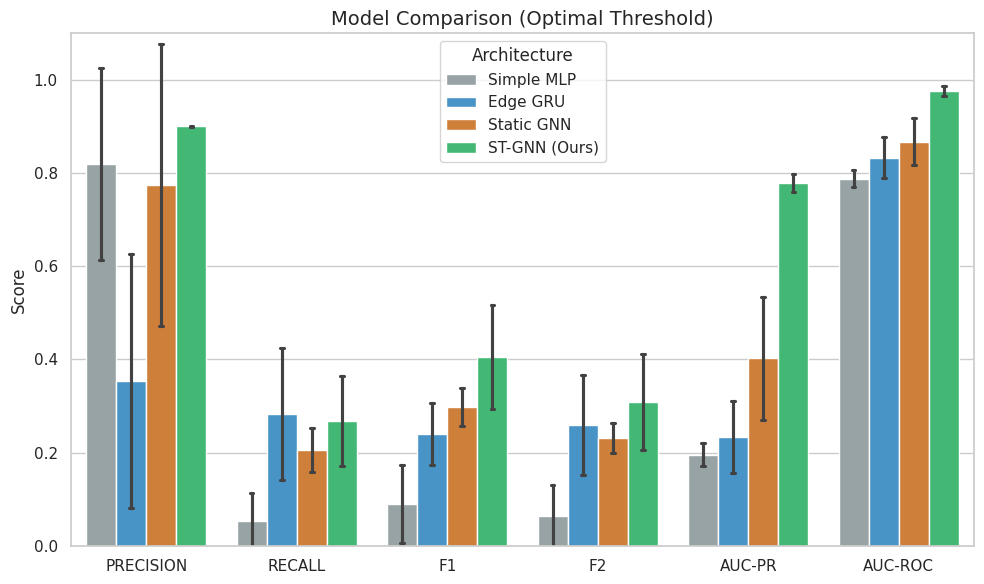


4. Generating Radar Chart...


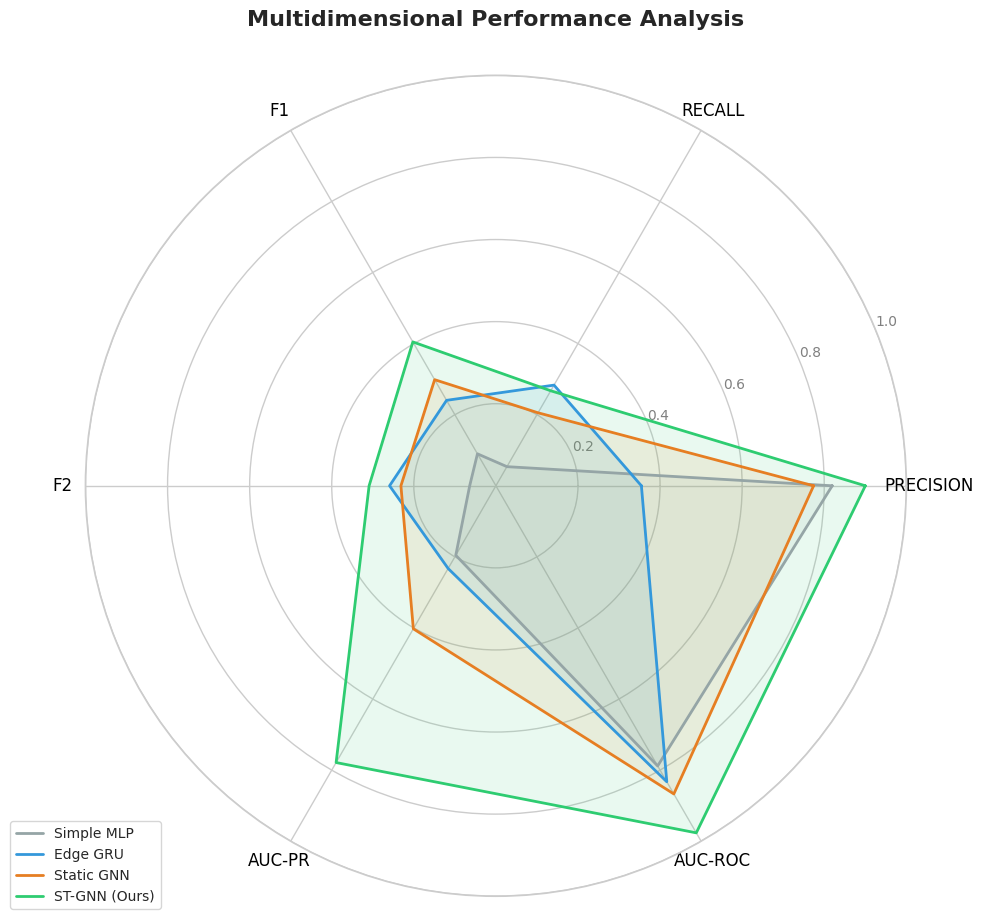


5. Generating Loss Curve Graphs...


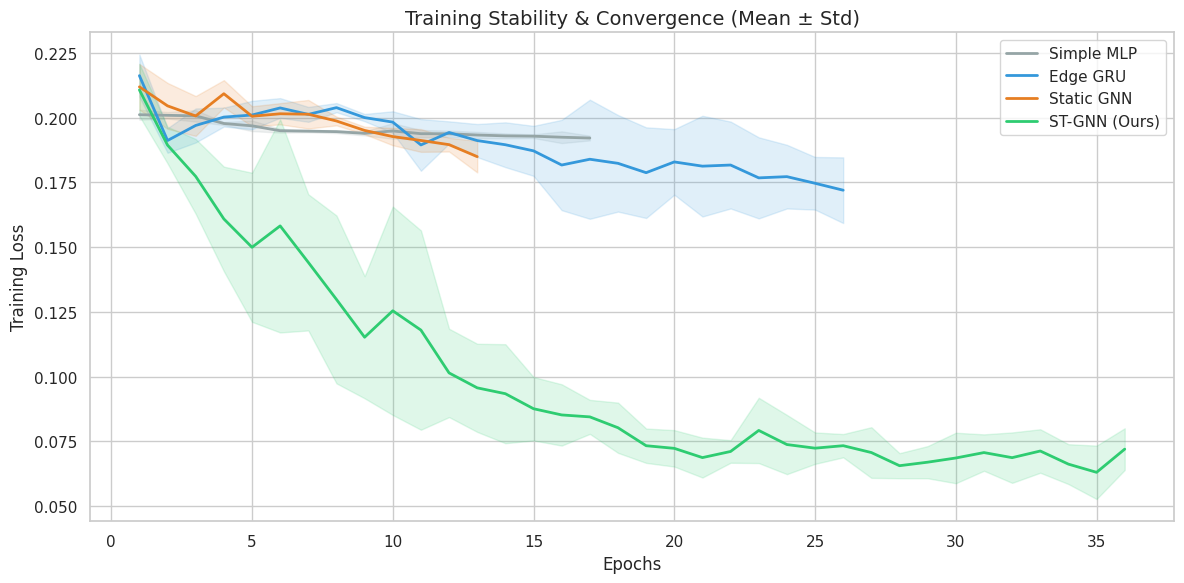

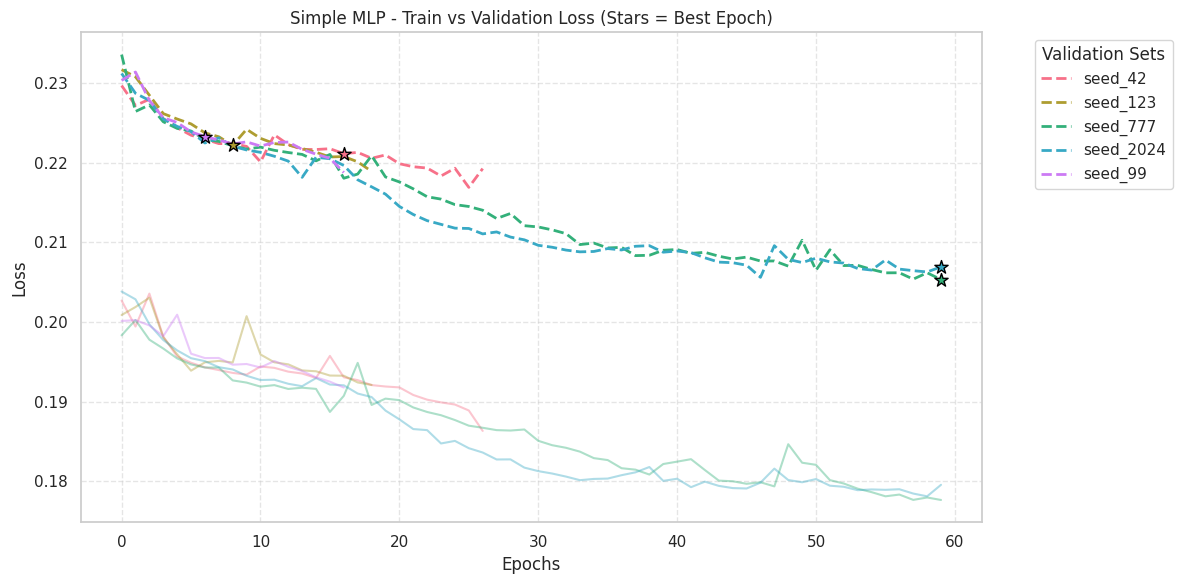

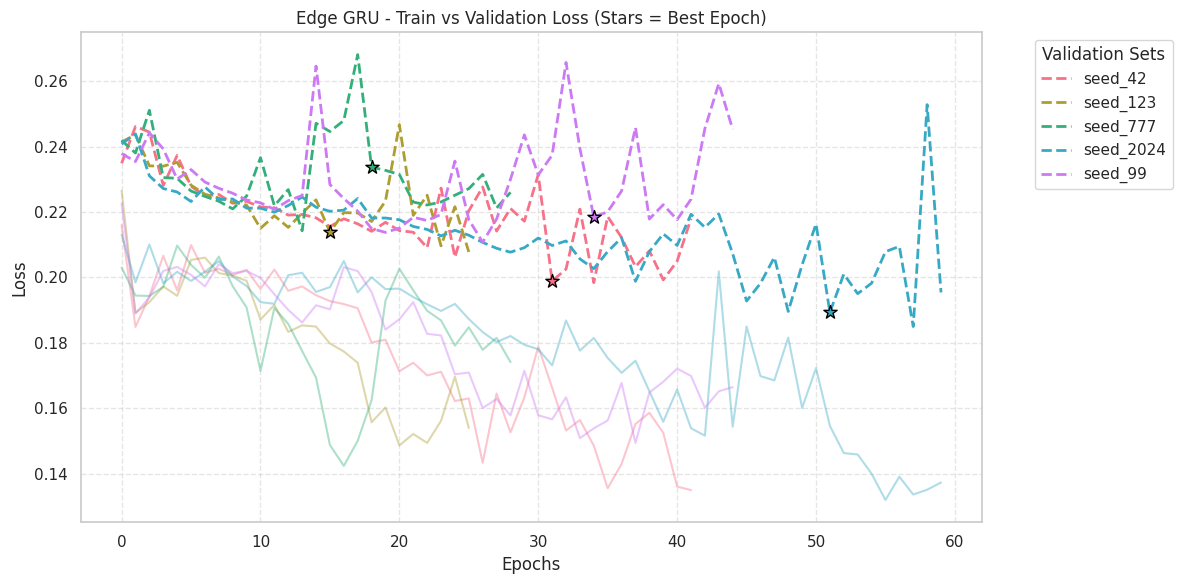

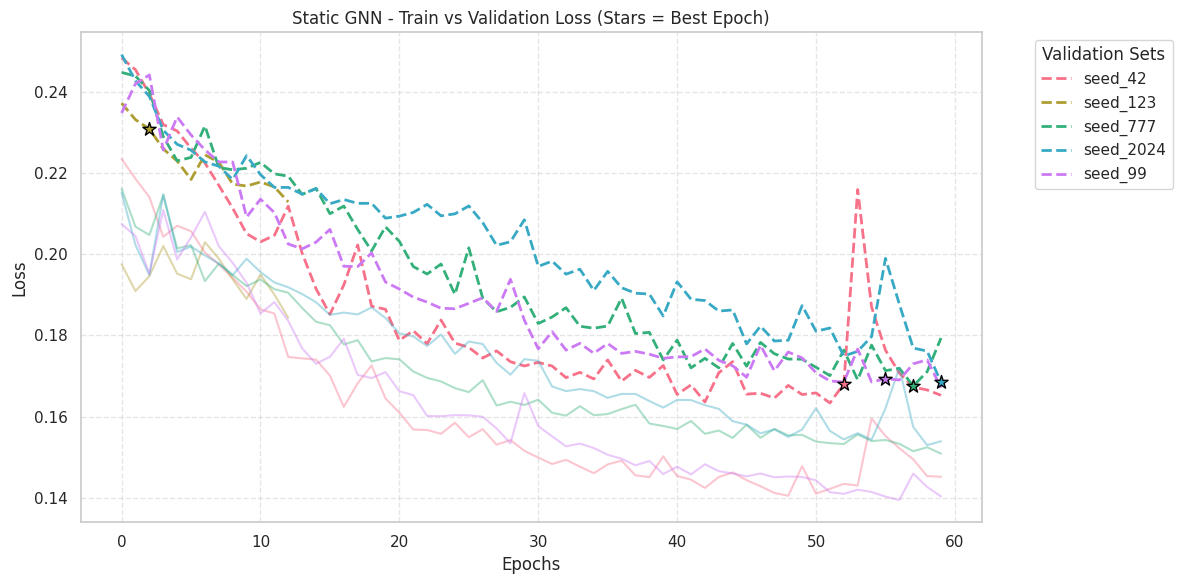

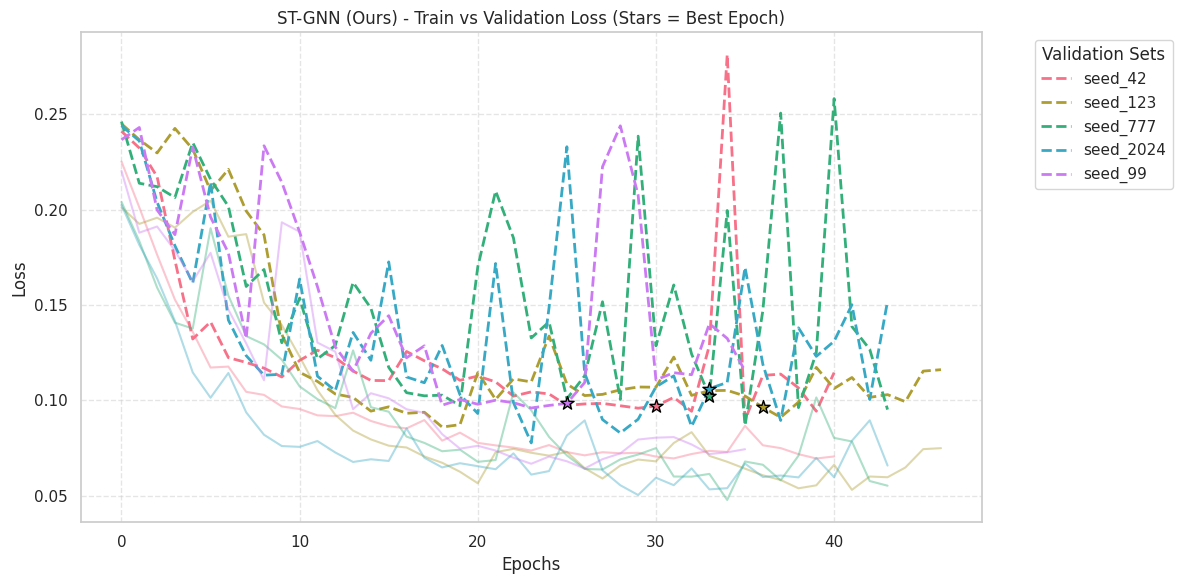


Analysis complete. Charts saved in folder ./results_earlystopping/plots


In [17]:
print("1. Loading data...")
losses_data = load_json_losses(LOGS_DIR)
df_metrics = load_and_merge_csv_data(LOGS_DIR)

if df_metrics is not None:
    print("\n2. Generating Summary Table...")
    generate_summary_table(df_metrics)

    print("\n3. Generating Comparison Chart (Bar Chart)...")
    plot_comparison(df_metrics, PLOTS_DIR)

    print("\n4. Generating Radar Chart...")
    plot_radar_chart(df_metrics, PLOTS_DIR)
else:
    print("No metrics CSV files were found")

if losses_data:
    print("\n5. Generating Loss Curve Graphs...")
    plot_training_losses(losses_data, PLOTS_DIR)
    for raw_model_name in losses_data.keys():
        plot_losses_train_val_per_model(losses_data, raw_model_name, PLOTS_DIR)
else:
    print("No losses JSON files were found")

print(f"\nAnalysis complete. Charts saved in folder {PLOTS_DIR}")